## Carga de datos.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import matplotlib.pylab as plt
from scipy import stats
import os # accessing directory structure

import seaborn as sns
sns.set_theme(color_codes=True)

df1 = pd.read_csv('data/chickweight.csv', delimiter=',')

# Exploración de datos

In [2]:
df1.dataframeName = 'chickweight.csv'
nRow, nCol = df1.shape
print(f'Tenemos {nRow} filas y {nCol} columnas.')

print(f'Sabemos que los datos son obtenidos de un estudio con pollos.')
print(f'La columna Time, indica la edad en días del pollo.                      Entero entre {df1.Time.min()} y {df1.Time.max()}')
print(f'La columna Chick, indica el identificador único para cada pollo.        Entero entre {df1.Chick.min()} y {df1.Chick.max()}')
print(f'La columna Diet, indica el tipo de dieta que siguió ese pollo.          Entero entre {df1.Diet.min()} y {df1.Diet.max()}')
print(f'La columna Weight, indica el peso del pollo en el momento de medisión.  Entero entre {df1.weight.min()} y {df1.weight.max()}')

Tenemos 578 filas y 4 columnas.
Sabemos que los datos son obtenidos de un estudio con pollos.
La columna Time, indica la edad en días del pollo.                      Entero entre 0 y 21
La columna Chick, indica el identificador único para cada pollo.        Entero entre 1 y 50
La columna Diet, indica el tipo de dieta que siguió ese pollo.          Entero entre 1 y 4
La columna Weight, indica el peso del pollo en el momento de medisión.  Entero entre 35 y 373


In [3]:
df1.groupby('Time').agg(
    min_weight=('weight', 'min'),
    max_weight=('weight', 'max'),
    avg_weight=('weight', 'mean'),
    num_chicks=('Chick', 'count'),
    total_weight=('weight', 'sum'),
)

,min_weight,max_weight,avg_weight,num_chicks,total_weight
Time,,,,,
0,39,43,41.060000,50,2053
2,35,55,49.220000,50,2461
4,48,69,59.959184,49,2938
6,51,96,74.306122,49,3641
8,57,131,91.244898,49,4471
10,51,163,107.836735,49,5284
12,54,217,129.244898,49,6333
14,68,240,143.812500,48,6903
16,71,287,168.085106,47,7900


## Preprocesamiento

# Pivotamos los datos para identificar los pollos que no llegaron a final del experimento, y por tanto, sus datos faltan.

In [4]:
chicks_pivot = df1.pivot_table(values="weight", index=['Chick', 'Diet'], columns='Time')
chicks_pivot.head(10)

,Time,0,2,4,6,8,10,12,14,16,18,20,21
Chick,Diet,,,,,,,,,,,,
1,1,42.0,51.0,59.0,64.0,76.0,93.0,106.0,125.0,149.0,171.0,199.0,205.0
2,1,40.0,49.0,58.0,72.0,84.0,103.0,122.0,138.0,162.0,187.0,209.0,215.0
3,1,43.0,39.0,55.0,67.0,84.0,99.0,115.0,138.0,163.0,187.0,198.0,202.0
4,1,42.0,49.0,56.0,67.0,74.0,87.0,102.0,108.0,136.0,154.0,160.0,157.0
5,1,41.0,42.0,48.0,60.0,79.0,106.0,141.0,164.0,197.0,199.0,220.0,223.0
6,1,41.0,49.0,59.0,74.0,97.0,124.0,141.0,148.0,155.0,160.0,160.0,157.0
7,1,41.0,49.0,57.0,71.0,89.0,112.0,146.0,174.0,218.0,250.0,288.0,305.0
8,1,42.0,50.0,61.0,71.0,84.0,93.0,110.0,116.0,126.0,134.0,125.0,NaN
9,1,42.0,51.0,59.0,68.0,85.0,96.0,90.0,92.0,93.0,100.0,100.0,98.0


# Eliminamos los datos faltantes y volvemos al formato inicial de los datos.

In [ ]:
chicks_pivot = chicks_pivot.dropna();
chicks = chicks_pivot.stack().reset_index(name='weight')

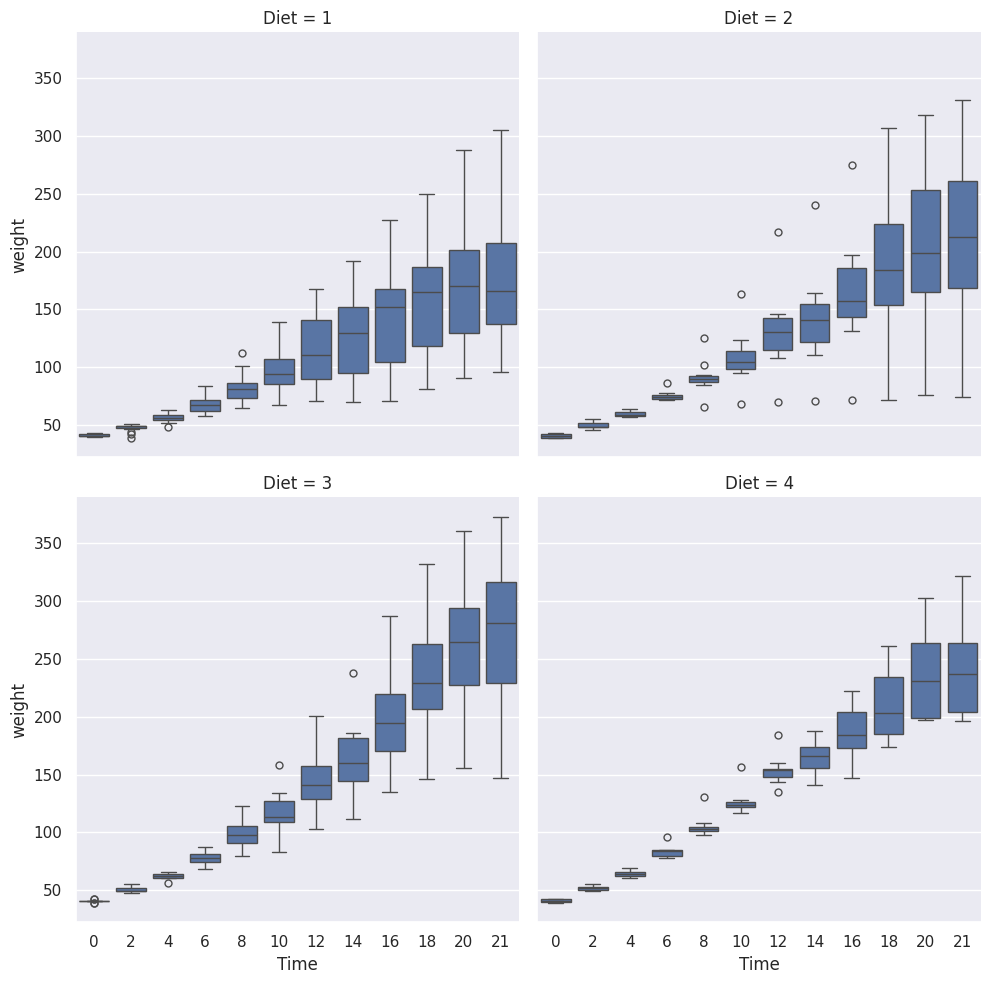

In [10]:
sns.catplot(x="Time", y="weight", col="Diet", data=chicks, kind="box", col_wrap=2)

## Modelo entrenado

In [ ]:
from sklearn.model_selection import train_test_split

# y = WEIGHT -> target
y = chicks.weight
# X = ["Diet", "Time"] -> features
features = ["Diet", "Time"]
X = chicks[features]

## Evaluación sobre test